## Unsupervised Learning & Feature Engineering

**Objective:**
The objective of this notebook is to perform data preprocessing, feature engineering, clustering, dimensionality reduction, anomaly detection, and feature engineering experiments on different datasets. Each step is implemented and explained to demonstrate its impact on machine learning models.

## Part 1: Data Preprocessing

**Datasets Used**
- Wine Quality Dataset (Numerical Heavy)
- Adult Census Dataset (Mixed Numerical & Categorical)
- Mall Customers Dataset (Clustering Project)

#### Import Libraries

In [151]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer

# Feature Selection
from sklearn.feature_selection import VarianceThreshold, RFE

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

# Evaluation Metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.metrics import silhouette_samples


# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Utilities
import warnings
warnings.filterwarnings("ignore")

# Plot Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures


#### Loading Dataset

In [75]:
adult_df = pd.read_csv("data/raw/adult_census_dataset.csv")
wine_df = pd.read_csv("data/raw/wine_quality_dataset.csv")


In [76]:
# Displaying dataset shapes
print("Adult Census Dataset:", adult_df.shape)
print("Wine Quality Dataset:", wine_df.shape)


Adult Census Dataset: (32561, 15)
Wine Quality Dataset: (1599, 12)


In [77]:
print("Adult Census Dataset")
display(adult_df.head())
print("\nWine Quality Dataset")
display(wine_df.head())


Adult Census Dataset


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K



Wine Quality Dataset


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### Exploratory Data Analysis (EDA)

In [79]:
# Dataset information
print("Adult Census Dataset")
adult_df.info()
print("\n" + "="*80 + "\n")
print("Wine Quality Dataset")
wine_df.info()


Adult Census Dataset
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


Wine Quality Dataset
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (tota

In [80]:
# Summary statistics
print("Adult Census Dataset")
display(adult_df.describe(include="all"))
print("Wine Quality Dataset")
display(wine_df.describe(include="all"))


Adult Census Dataset


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


Wine Quality Dataset


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### Data Preprocessing

#### Handling Missing Values

The first step in data preprocessing is identifying missing values. Since missing data can affect the quality of analysis and model performance, it should be detected and handled before moving to the next preprocessing steps. In the Adult Census dataset, missing values are stored as `?`, whereas the Wine Quality dataset does not contain missing values.

In [81]:
# Checking for missing values
print("Adult Census Dataset")
print(adult_df.isnull().sum())
print("\nWine Quality Dataset")
print(wine_df.isnull().sum())


Adult Census Dataset
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Wine Quality Dataset
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [82]:
# Check for missing values represented as '?'
for column in adult_df.select_dtypes(include="object").columns:
    count = adult_df[column].astype(str).str.strip().eq("?").sum()
    if count > 0:
        print(f"{column}: {count}")


workclass: 1836
occupation: 1843
native.country: 583


In [83]:
# Replace '?' with NaN
adult_df.replace(["?", " ?"], np.nan, inplace=True)
print(adult_df.isnull().sum())


age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [84]:
# Fill missing categorical values with the mode
categorical_columns = ["workclass", "occupation", "native.country"]
for column in categorical_columns:
    adult_df[column] = adult_df[column].fillna(adult_df[column].mode()[0])

print("Adult Census Dataset")
print(adult_df.isnull().sum())
print("\nWine Quality Dataset")
print(wine_df.isnull().sum())


Adult Census Dataset
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Wine Quality Dataset
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


**Observation**

The `?` values in the Adult Census dataset were converted to `NaN` and replaced using the mode of their respective columns. After imputation, both datasets were free of missing values and ready for further preprocessing.


#### Removing Duplicates

Duplicate records can introduce bias and affect the accuracy of data analysis and machine learning models. It is good practice to check for duplicate entries and remove them before proceeding with further preprocessing.

In [85]:
# Check duplicate records
print("Adult Census Dataset")
print("Duplicate Rows:", adult_df.duplicated().sum())
print("\nWine Quality Dataset")
print("Duplicate Rows:", wine_df.duplicated().sum())


Adult Census Dataset
Duplicate Rows: 24

Wine Quality Dataset
Duplicate Rows: 240


In [86]:
# Removing duplicate records
adult_df = adult_df.drop_duplicates()
wine_df = wine_df.drop_duplicates()

print("Adult Census Dataset")
print("Duplicate Rows:", adult_df.duplicated().sum())
print("Shape:", adult_df.shape)
print("\nWine Quality Dataset")
print("Duplicate Rows:", wine_df.duplicated().sum())
print("Shape:", wine_df.shape)


Adult Census Dataset
Duplicate Rows: 0
Shape: (32537, 15)

Wine Quality Dataset
Duplicate Rows: 0
Shape: (1359, 12)


**Observation**

Duplicate records were found in both datasets and removed successfully. This helps ensure that repeated observations do not bias the analysis or influence the machine learning models.

#### Handling Outliers

Outliers are data points that differ significantly from the rest of the observations. They can influence statistical analysis and machine learning models, so it is important to identify them before model training. In this section, the IQR (Interquartile Range) method is used to detect outliers in the numerical features of both datasets.

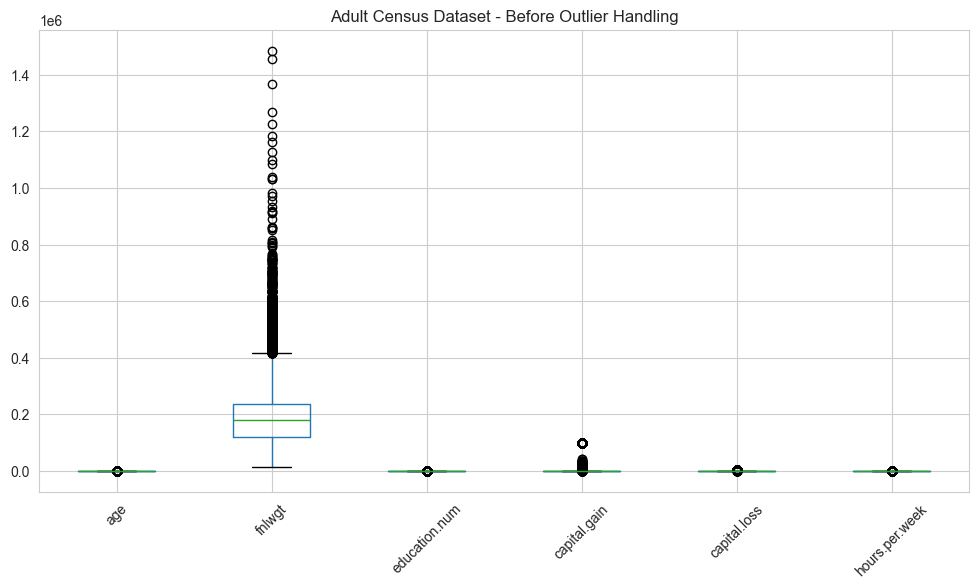

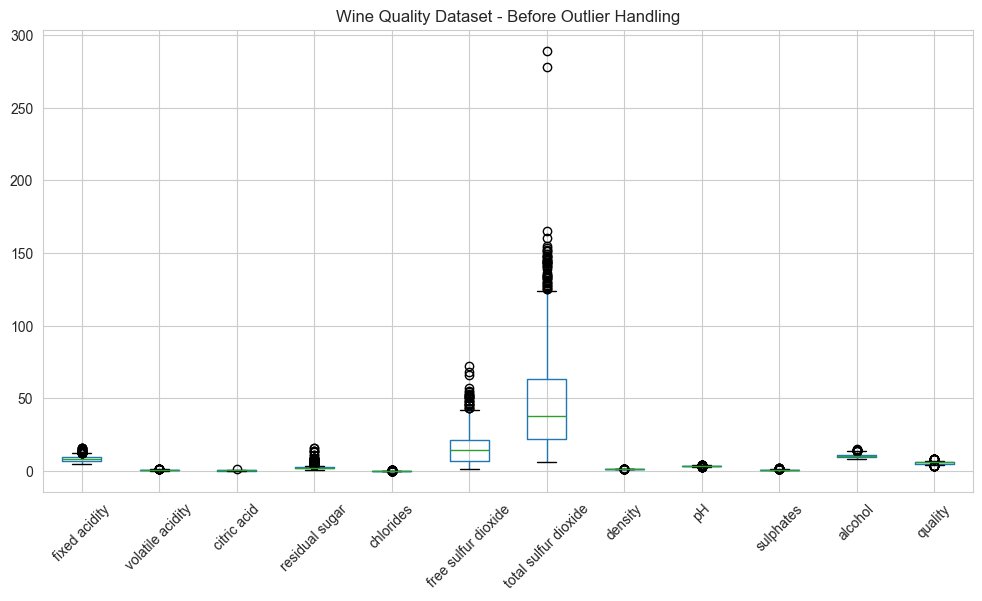

In [87]:
adult_numeric = adult_df.select_dtypes(include=np.number)
wine_numeric = wine_df.select_dtypes(include=np.number)
# Adult Census Dataset
plt.figure(figsize=(12, 6))
adult_numeric.boxplot(rot=45)
plt.title("Adult Census Dataset - Before Outlier Handling")
plt.show()
# Wine Quality Dataset
plt.figure(figsize=(12, 6))
wine_numeric.boxplot(rot=45)
plt.title("Wine Quality Dataset - Before Outlier Handling")
plt.show()


The IQR (Interquartile Range) method is used to identify potential outliers in numerical features. Values below the lower bound or above the upper bound are considered outliers.

In [88]:
# Function to count outliers using the IQR method
def count_outliers(df):
    numeric_columns = df.select_dtypes(include=np.number).columns
    for column in numeric_columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        print(f"{column}: {len(outliers)} outliers")

print("Adult Census Dataset")
count_outliers(adult_df)
print("\n" + "=" * 60 + "\n")
print("Wine Quality Dataset")
count_outliers(wine_df)


Adult Census Dataset
age: 142 outliers
fnlwgt: 993 outliers
education.num: 1193 outliers
capital.gain: 2712 outliers
capital.loss: 1519 outliers
hours.per.week: 9002 outliers


Wine Quality Dataset
fixed acidity: 41 outliers
volatile acidity: 19 outliers
citric acid: 1 outliers
residual sugar: 126 outliers
chlorides: 87 outliers
free sulfur dioxide: 26 outliers
total sulfur dioxide: 45 outliers
density: 35 outliers
pH: 28 outliers
sulphates: 55 outliers
alcohol: 12 outliers
quality: 27 outliers


**Observation**

Outliers were identified using the IQR method. Since many of these observations may represent valid data rather than errors, no records were removed. The detected outliers were retained for subsequent analysis.

#### Encoding Categorical Variables

Machine learning algorithms require numerical input, so categorical features must be converted into a numerical format. In this section, Label Encoding and One-Hot Encoding are applied to the Adult Census dataset.

In [89]:
# Display categorical columns
categorical_columns = adult_df.select_dtypes(include="object").columns.tolist()
print("Categorical Columns:")
print(categorical_columns)


Categorical Columns:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


In [90]:
# Label Encoding the target variable
label_encoder = LabelEncoder()
adult_df["income"] = label_encoder.fit_transform(adult_df["income"])
adult_df["income"].head()


0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64

In [91]:
# Applying One-Hot Encoding to categorical features
one_hot_columns = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]
adult_encoded = pd.get_dummies(
    adult_df,
    columns=one_hot_columns,
    drop_first=True
)
print("Original Shape:", adult_df.shape)
print("Encoded Shape:", adult_encoded.shape)


Original Shape: (32537, 15)
Encoded Shape: (32537, 98)


**Observation**

The target variable (`income`) was converted into numerical labels using Label Encoding. The remaining categorical features were transformed using One-Hot Encoding to create a machine learning–ready dataset while avoiding any artificial ordering between categories.

#### Feature Scaling

Feature scaling ensures that numerical features are on a similar scale. This is especially important for distance-based algorithms such as K-Means, PCA, and K-Nearest Neighbors. In this section, StandardScaler, MinMaxScaler, and RobustScaler are applied and compared.

In [92]:
# Check data types after One-Hot Encoding
adult_encoded.dtypes.value_counts()


bool     91
int64     7
Name: count, dtype: int64

In [93]:
# Select numerical features
adult_numeric = adult_encoded.select_dtypes(include=np.number)
wine_numeric = wine_df.select_dtypes(include=np.number)
print("Adult Census Dataset:", adult_numeric.shape)
print("Wine Quality Dataset:", wine_numeric.shape)


Adult Census Dataset: (32537, 7)
Wine Quality Dataset: (1359, 12)


#### Standard scaler

In [94]:
# Apply StandardScaler
standard_scaler = StandardScaler()
adult_standard = pd.DataFrame(
    standard_scaler.fit_transform(adult_numeric),
    columns=adult_numeric.columns
)
wine_standard = pd.DataFrame(
    standard_scaler.fit_transform(wine_numeric),
    columns=wine_numeric.columns
)
print("Standard Scaling completed.")
adult_standard.head()


Standard Scaling completed.


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,3.770003,-1.067955,-0.420679,-0.145975,10.589625,-0.035664,-0.563377
1,3.183397,-0.539159,-0.420679,-0.145975,10.589625,-1.817516,-0.563377
2,2.010185,-0.035241,-0.031815,-0.145975,10.589625,-0.035664,-0.563377
3,1.130276,-0.468210,-2.364998,-0.145975,9.458380,-0.035664,-0.563377
4,0.177041,0.709415,-0.031815,-0.145975,9.458380,-0.035664,-0.563377


#### MinMaxScaler

In [95]:
# Apply MinMaxScaler
minmax_scaler = MinMaxScaler()
adult_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(adult_numeric),
    columns=adult_numeric.columns
)
wine_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(wine_numeric),
    columns=wine_numeric.columns
)
print("MinMax Scaling completed.")
adult_minmax.head()


MinMax Scaling completed.


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,1.000000,0.043987,0.533333,0.0,1.000000,0.397959,0.0
1,0.890411,0.081896,0.533333,0.0,1.000000,0.173469,0.0
2,0.671233,0.118021,0.600000,0.0,1.000000,0.397959,0.0
3,0.506849,0.086982,0.200000,0.0,0.895317,0.397959,0.0
4,0.328767,0.171404,0.600000,0.0,0.895317,0.397959,0.0


#### RobustScaler

In [96]:
# Apply RobustScaler
robust_scaler = RobustScaler()
adult_robust = pd.DataFrame(
    robust_scaler.fit_transform(adult_numeric),
    columns=adult_numeric.columns
)
wine_robust = pd.DataFrame(
    robust_scaler.fit_transform(wine_numeric),
    columns=wine_numeric.columns
)
print("Robust Scaling completed.")
adult_robust.head()


Robust Scaling completed.


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income
0,2.65,-0.850100,-0.333333,0.0,4356.0,0.0,0.0
1,2.25,-0.381703,-0.333333,0.0,4356.0,-4.4,0.0
2,1.45,0.064658,0.000000,0.0,4356.0,0.0,0.0
3,0.85,-0.318858,-2.000000,0.0,3900.0,0.0,0.0
4,0.20,0.724259,0.000000,0.0,3900.0,0.0,0.0


**Observation**

Three feature scaling techniques were applied to both datasets. StandardScaler standardizes the data, MinMaxScaler scales values to a range between 0 and 1, and RobustScaler reduces the effect of outliers by using the median and interquartile range.

#### Feature Selection

Feature selection helps identify the most relevant features for model training. It reduces unnecessary information, improves model efficiency, and can enhance predictive performance. The following techniques are used: Correlation, Variance Threshold, and Recursive Feature Elimination (RFE).

#### Correlation Analysis

Correlation analysis measures the relationship between numerical features. A correlation heatmap helps identify strongly related features and can reveal multicollinearity within the dataset.

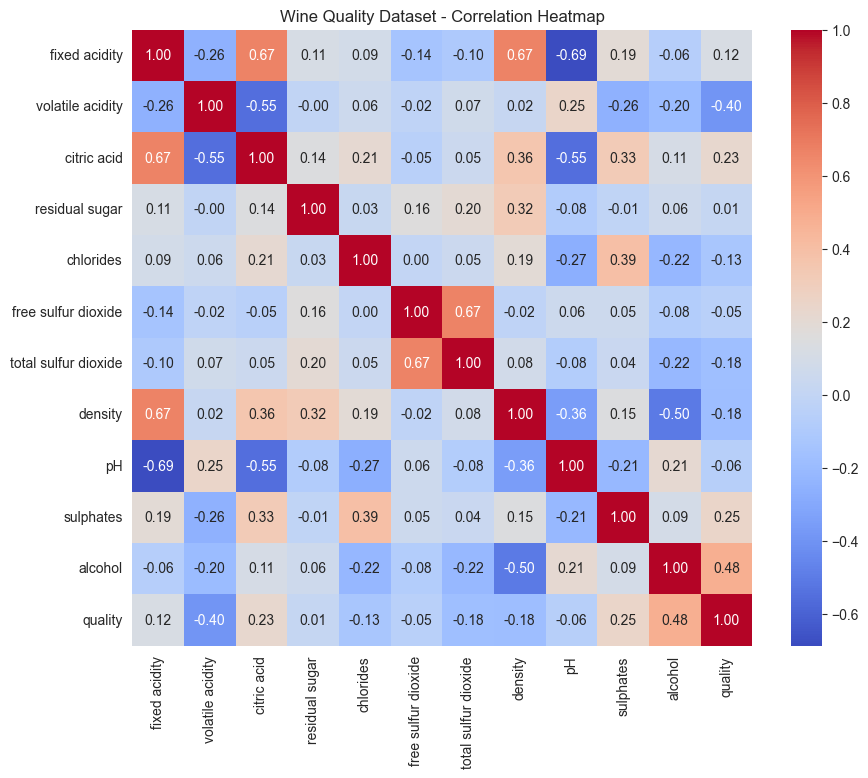

In [97]:
# Correlation matrix for the Wine Quality dataset
plt.figure(figsize=(10, 8))
sns.heatmap(
    wine_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Wine Quality Dataset - Correlation Heatmap")
plt.show()


#### Variance Threshold

Variance Threshold removes features with little or no variation. Features that remain almost constant across all observations usually contribute very little to machine learning models.

In [98]:
selector = VarianceThreshold(threshold=0.01)

adult_variance = selector.fit_transform(adult_standard)
selected_features = adult_standard.columns[selector.get_support()]

print("Original Features:", adult_standard.shape[1])
print("Selected Features:", len(selected_features))
print("\nSelected Features:")
print(selected_features.tolist())


Original Features: 7
Selected Features: 7

Selected Features:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'income']


**Observation**

Using a variance threshold of `0.01`, no features were removed because all features contained sufficient variation. This indicates that every feature contributed some level of information to the dataset.

#### Recursive Feature Elimination (RFE)

Recursive Feature Elimination (RFE) selects the most important features by repeatedly training a model and removing the least significant features until the desired number of features remains.

In [99]:
# Prepare features and target for RFE
X = adult_encoded.drop("income", axis=1)
y = adult_encoded["income"]

print("Features:", X.shape)
print("Target:", y.shape)
print("Unique Target Values:", y.unique())


Features: (32537, 97)
Target: (32537,)
Unique Target Values: [0 1]


In [100]:
# Apply Recursive Feature Elimination (RFE)
model = LogisticRegression(max_iter=1000)
rfe = RFE(
    estimator=model,
    n_features_to_select=10
)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Number of Selected Features:", len(selected_features))
print("\nSelected Features:")
print(selected_features.tolist())


Number of Selected Features: 10

Selected Features:
['education_1st-4th', 'education_Doctorate', 'education_Masters', 'education_Prof-school', 'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse', 'occupation_Priv-house-serv', 'relationship_Own-child', 'native.country_Columbia', 'native.country_Mexico']


**Observation**

RFE selected the ten most relevant features from the Adult Census dataset using Logistic Regression. These selected features can be used to reduce the dimensionality of the dataset while retaining the most informative variables for prediction.

## Part 2 : Clustering

#### K-Means Clustering

K-Means is an unsupervised learning algorithm that groups similar data points into K clusters. It works by assigning each point to the nearest centroid and updating the centroids iteratively until the clusters become stable.

In [101]:
# Prepare data for clustering
wine_cluster = wine_standard.copy()
print("Dataset Shape:", wine_cluster.shape)
wine_cluster.head()


Dataset Shape: (1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374,-0.757040
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575,-0.757040
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575,-0.757040
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575,0.457621
4,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374,-0.757040


In [102]:
# Remove the target column before clustering
X_wine = wine_standard.drop("quality", axis=1)
print("Shape after removing target column:", X_wine.shape)
X_wine.head()


Shape after removing target column: (1359, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575
4,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374


**Why is the `quality` column removed?**

Clustering is an unsupervised learning technique, which means it should not use target labels during training. The `quality` column represents the wine quality score, so it is removed before applying clustering algorithms.

**Choosing the Optimal Number of Clusters (Elbow Method)**

The Elbow Method helps determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS) for different values of K. The point where the decrease in WCSS starts to slow down (forming an "elbow") is considered a good choice for K.

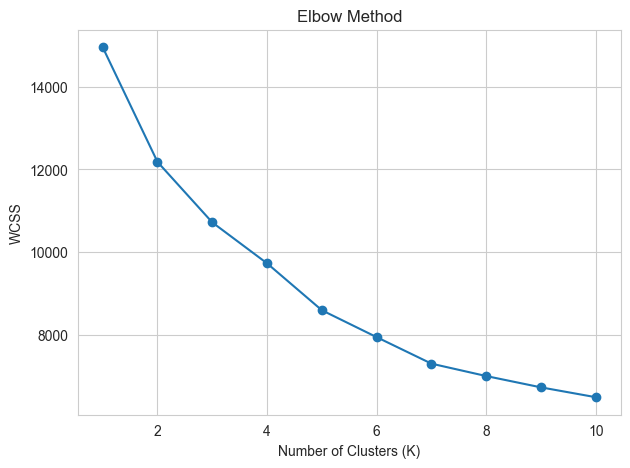

In [103]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_wine)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


**Observation**

The elbow appears around **K = 5**, where the decrease in WCSS starts to slow down. Therefore, **5 clusters** are selected for the K-Means model.

##### K-Means Model

After selecting the optimal number of clusters using the Elbow Method, the K-Means algorithm is trained with **K = 5** to assign each data point to a cluster.

In [104]:
# Train K-Means with the selected number of clusters

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
wine_clusters = kmeans.fit_predict(X_wine)
print("Cluster Labels (first 10):")
print(wine_clusters[:10])

Cluster Labels (first 10):
[2 2 2 1 2 2 2 2 0 2]


**Observation**

The K-Means model successfully assigned each wine sample to one of the five clusters. The cluster labels are identifiers used to distinguish different groups of similar observations.

#### Silhouette Score

The Silhouette Score measures how well the data points fit within their assigned clusters. A higher score indicates better-defined and more separated clusters.

In [105]:
sil_score = silhouette_score(X_wine, wine_clusters)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.1891


**Observation**

The Silhouette Score of **0.1891** indicates that the clusters are not well separated and there is some overlap between them. This suggests that the Wine Quality dataset does not have a strong natural clustering structure using K-Means with five clusters.

#### Silhouette Plot

The Silhouette Plot visualizes how well each data point fits within its assigned cluster. It helps assess the quality and separation of the clusters.

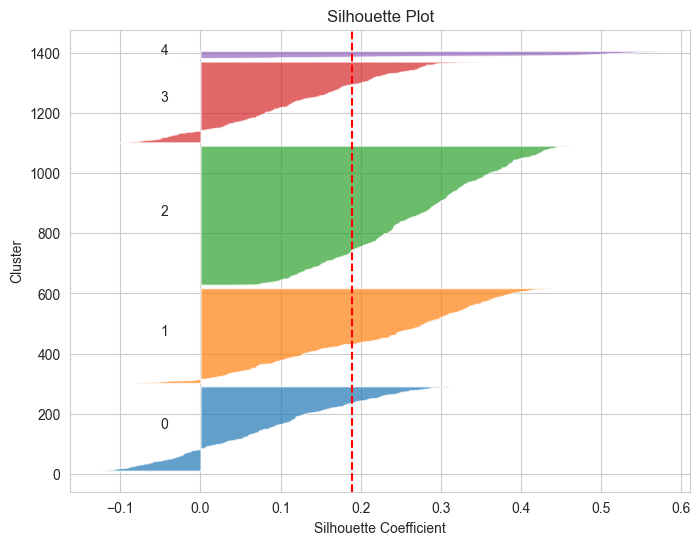

In [106]:
sample_silhouette_values = silhouette_samples(X_wine, wine_clusters)
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10

for i in range(5):
    values = sample_silhouette_values[wine_clusters == i]
    values.sort()

    size_cluster = values.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        values,
        alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))

    y_lower = y_upper + 10

ax.axvline(x=sil_score, color="red", linestyle="--")
ax.set_title("Silhouette Plot")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
plt.show()


**Observation**

The Silhouette Plot shows that most samples have positive silhouette values, indicating reasonable cluster assignments. However, many points are close to zero and a few are negative, suggesting overlap between clusters. This agrees with the Silhouette Score and indicates that the Wine Quality dataset does not have strongly separated clusters using K-Means.

#### Hierarchical Clustering

Hierarchical Clustering is an unsupervised learning algorithm that groups similar data points into a hierarchy of clusters. Unlike K-Means, it does not require the number of clusters to be specified initially and represents the clustering process using a dendrogram.

**Key Concepts**

- **Agglomerative Clustering:** A bottom-up approach where each data point starts as its own cluster and the closest clusters are merged step by step.

- **Divisive Clustering:** A top-down approach where all data points start in one cluster and are split into smaller clusters recursively.

- **Linkage Methods:** These define how the distance between clusters is calculated. Common methods include Single, Complete, Average, and Ward linkage.

- **Dendrogram:** A tree-like diagram that illustrates how clusters are merged and helps estimate an appropriate number of clusters.

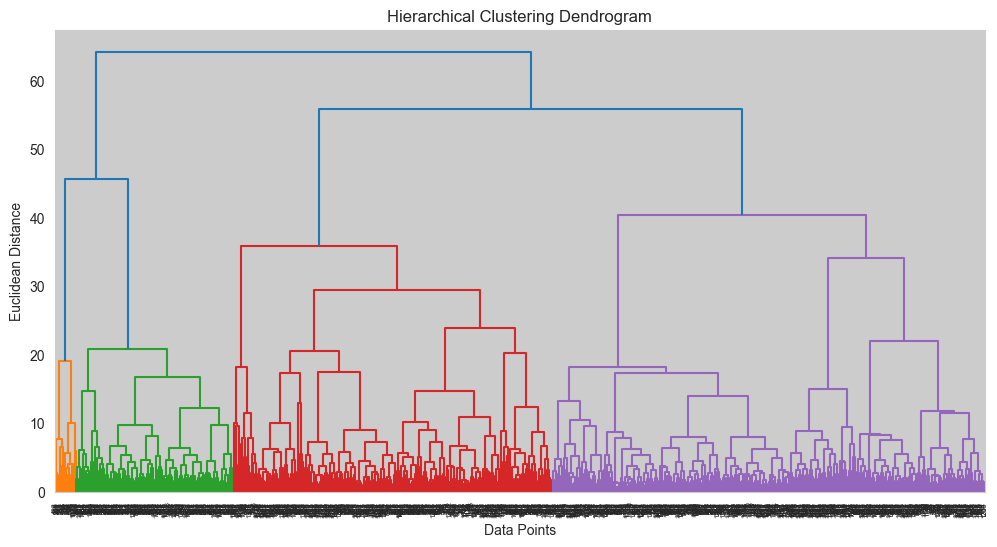

In [107]:
# Generate Dendogram

# Create linkage matrix
linked = linkage(X_wine, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()


**Observation**

The dendrogram suggests that dividing the data into **three clusters** is a reasonable choice, as the largest vertical gap appears before the final major cluster merges.

#### Agglomerative Clustering

Agglomerative Clustering is a bottom-up hierarchical clustering algorithm. It begins by treating each data point as an individual cluster and repeatedly merges the two closest clusters until the desired number of clusters is obtained.

In [108]:
# Train Agglomerative Clustering
agglomerative = AgglomerativeClustering(n_clusters=3)
agg_clusters = agglomerative.fit_predict(X_wine)
print("Cluster Labels (first 10):")
print(agg_clusters[:10])


Cluster Labels (first 10):
[1 2 2 0 1 2 1 1 2 1]


**Observation**

The Agglomerative Clustering model assigned each wine sample to one of the three clusters identified from the dendrogram. Unlike K-Means, Hierarchical Clustering builds a hierarchy of clusters instead of relying on cluster centroids.

**Divisive Clustering**

Divisive Clustering is a top-down hierarchical approach. It starts with all data points in a single cluster and repeatedly splits them into smaller clusters until each observation forms its own cluster or a stopping condition is reached. It is less commonly used because it is computationally more expensive than Agglomerative Clustering.

**Linkage Methods**

Linkage methods determine how the distance between clusters is calculated during hierarchical clustering.

- **Single Linkage:** Uses the shortest distance between two clusters.
- **Complete Linkage:** Uses the farthest distance between two clusters.
- **Average Linkage:** Uses the average distance between all pairs of points in two clusters.
- **Ward Linkage:** Merges clusters by minimizing the increase in within-cluster variance. It generally produces compact and well-balanced clusters.

**Comparison: K-Means vs Hierarchical Clustering**

| K-Means | Hierarchical Clustering |
|---------|--------------------------|
| Requires the number of clusters in advance. | Does not require the number of clusters initially. |
| Uses centroids to form clusters. | Builds clusters by merging or splitting observations. |
| Faster for large datasets. | More computationally expensive. |
| Works well for spherical clusters. | Can capture hierarchical relationships between clusters. |

#### DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups closely packed data points into clusters while identifying isolated points as noise. Unlike K-Means, it does not require the number of clusters to be specified in advance.

**Key Concepts**

- **eps (Epsilon):** The maximum distance within which neighboring points are considered part of the same cluster.

- **min_samples:** The minimum number of neighboring points required to form a dense region.

- **Core Point:** A point that has at least `min_samples` neighbors within the `eps` distance.

- **Border Point:** A point that lies within the neighborhood of a core point but does not have enough neighbors to be a core point itself.

- **Noise Point:** A point that does not belong to any cluster because it is too far from other points.

In [109]:
# Apply DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_wine)
print("Cluster Labels (first 20):")
print(dbscan_clusters[:20])
print("\nUnique Cluster Labels:")
print(set(dbscan_clusters))


Cluster Labels (first 20):
[ 0 -1  0 -1  0  0 -1  0 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1  0]

Unique Cluster Labels:
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(-1)}


**Observation**

DBSCAN identified multiple clusters and labeled some observations as **noise (-1)**. These noise points do not belong to any dense region and are treated as outliers by the algorithm.

**When is DBSCAN Better than K-Means?**

DBSCAN is preferred when the dataset contains noise or outliers, when the number of clusters is unknown, or when clusters have irregular shapes. In contrast, K-Means performs better on datasets with compact, spherical clusters and requires the number of clusters to be specified beforehand.

##  Part 3 – Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is a dimensionality reduction technique that converts many correlated features into a smaller number of principal components while preserving as much information (variance) as possible.

#### Covariance Matrix
The covariance matrix measures how features vary together. PCA uses this matrix to identify relationships between variables.

#### Eigenvalues
Eigenvalues represent the amount of variance explained by each principal component. Larger eigenvalues indicate more important components.

#### Eigenvectors
Eigenvectors determine the direction of each principal component. They define the new feature space after transformation.

#### Explained Variance
Explained variance indicates how much information is retained by each principal component.

##### Choosing the Number of Components
The cumulative explained variance is used to determine the optimal number of principal components. Components are selected until they explain a sufficient percentage of the total variance (commonly 90–95%, depending on the application).

#### Applying PCA using the wine dataset because it's numerical.

In [110]:
# Apply PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_wine_pca = pca.fit_transform(X_wine)

print("Original Shape:", X_wine.shape)
print("Reduced Shape:", X_wine_pca.shape)
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


Original Shape: (1359, 11)
Reduced Shape: (1359, 2)

Explained Variance Ratio:
[0.28293989 0.17347505]


**Observation**

- The original dataset contains 11 features.
- PCA reduced the dataset to 2 principal components.
- The first principal component explains approximately 28.29% of the variance.
- The second principal component explains approximately 17.35% of the variance.
- Together, they preserve about 45.64% of the total information, making the dataset suitable for visualization.

#### Visualization Before PCA

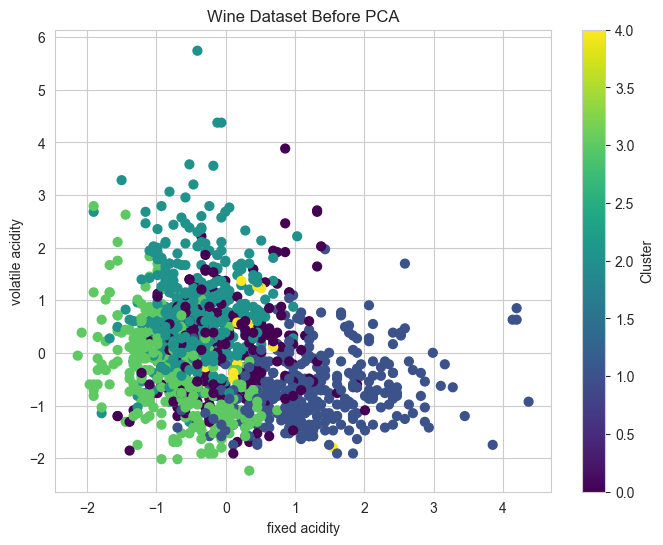

In [111]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_wine.iloc[:, 0],
    X_wine.iloc[:, 1],
    c=wine_clusters,
    cmap='viridis',
    s=40
)
plt.xlabel(X_wine.columns[0])
plt.ylabel(X_wine.columns[1])
plt.title("Wine Dataset Before PCA")
plt.colorbar(label="Cluster")
plt.show()


**Observation**

This plot shows the original data using the first two features. The clusters overlap considerably, making them difficult to distinguish. Compared with the PCA visualization, the transformed data provides a clearer separation between clusters.

#### Visualization After PCA

##### PCA Scatter Plot

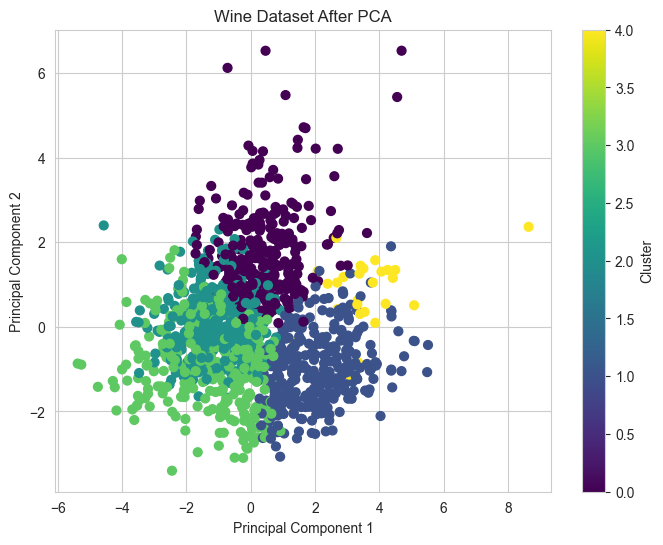

In [112]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_wine_pca[:, 0],
    X_wine_pca[:, 1],
    c=wine_clusters,
    cmap='viridis',
    s=40
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset After PCA")
plt.colorbar(label="Cluster")
plt.show()


**Observation**

The PCA-transformed data is projected onto two principal components. Compared to the original feature space, the clusters are more clearly separated, making the data easier to visualize and interpret.

#### Explained Variance

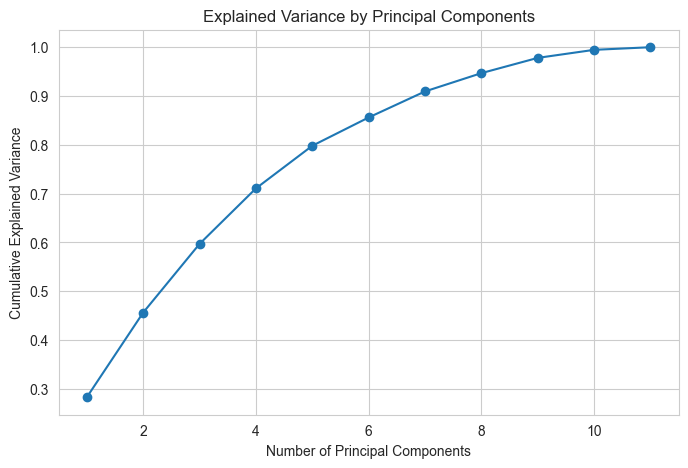

In [113]:
# Apply PCA using all components
pca_full = PCA()
pca_full.fit(X_wine)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.grid(True)
plt.show()


**Observation**

The cumulative explained variance increases as more principal components are added. This graph helps determine the optimal number of components required to retain most of the information while reducing the dimensionality of the dataset.

## Part 4 – Anomaly Detection

Anomaly Detection is an unsupervised machine learning technique used to identify unusual observations or outliers that differ significantly from the majority of the data. These anomalies may represent errors, rare events, or abnormal behavior.

In this section, the following algorithms are implemented:

- Isolation Forest
- Local Outlier Factor (LOF)

#### Isolation Forest

##### Working

Isolation Forest detects anomalies by randomly selecting a feature and splitting the data repeatedly. Since anomalies are rare and different from normal observations, they are isolated in fewer splits than regular data.

##### Advantages

- Fast and efficient for large datasets.
- Works well with high-dimensional data.
- Does not require labeled data.

##### Disadvantages

- Performance depends on the contamination parameter.
- May not perform well if anomalies are not clearly isolated.

In [114]:
# Apply Isolation Forest
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)
wine_standard["IsolationForest"] = iso.fit_predict(X_wine)
wine_standard["IsolationForest"].value_counts()


IsolationForest
 1    1291
-1      68
Name: count, dtype: int64

**Observation**

Isolation Forest identified 68 anomalous observations and 1291 normal observations. The algorithm successfully isolated a small proportion of the dataset as potential outliers, which is consistent with the specified contamination rate of 5%.

#### Local Outlier Factor (LOF)

##### Working

Local Outlier Factor (LOF) is a density-based anomaly detection algorithm. It compares the local density of a data point with the densities of its neighboring points. A point is considered an anomaly if its density is significantly lower than that of its neighbors.

##### Advantages

- Effective for detecting local anomalies.
- Performs well on datasets with varying densities.
- Does not assume any specific data distribution.

##### Disadvantages

- Computationally expensive for large datasets.
- Sensitive to the choice of the number of neighbors (`n_neighbors`).

In [115]:
# Apply Local Outlier Factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)
wine_standard["LOF"] = lof.fit_predict(X_wine)
wine_standard["LOF"].value_counts()


LOF
 1    1291
-1      68
Name: count, dtype: int64

**Observation**

Local Outlier Factor (LOF) detected 68 anomalous observations and 1291 normal observations. The results are consistent with the specified contamination rate, indicating that only a small portion of the dataset is considered anomalous.

#### Comparison: Isolation Forest vs Local Outlier Factor

| Feature | Isolation Forest | Local Outlier Factor (LOF) |
|---------|------------------|----------------------------|
| Approach | Tree-based | Density-based |
| Working | Randomly isolates anomalies | Compares local density with neighboring points |
| Speed | Faster | Slower |
| Suitable for Large Datasets | Yes | Less efficient |
| Detects Local Outliers | Moderate | Excellent |
| Requires Labels | No | No |

#### Conclusion

Both Isolation Forest and Local Outlier Factor detected the same number of anomalies in the wine dataset. Isolation Forest is more efficient for larger datasets due to its tree-based approach, while LOF is better at identifying anomalies based on local density differences. The choice of algorithm depends on the dataset characteristics and computational requirements.

## Part 5 – Clustering Project

**Dataset**

For this project, the **Mall Customers Dataset** is used. The dataset contains customer information such as Customer ID, Gender, Age, Annual Income, and Spending Score. The objective is to group customers into meaningful segments using different clustering algorithms.

##### Loading the Dataset

In [116]:
mall_df = pd.read_csv("data/raw/mall_customers_dataset.csv")
mall_df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


##### Dataset Information

In [117]:
print("Dataset Shape:", mall_df.shape)
print("\nDataset Information:")
mall_df.info()


Dataset Shape: (200, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


#### Data Preprocessing

**Encoding Categorical Variables**

The `Gender` feature is categorical and must be converted into numerical values before applying clustering algorithms.

In [118]:
mall_processed = mall_df.copy()
encoder = LabelEncoder()
mall_processed["Gender"] = encoder.fit_transform(mall_processed["Gender"])
mall_processed.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


**Removing Unnecessary Feature**

The `CustomerID` column is removed because it is a unique identifier and does not provide useful information for customer segmentation.

In [119]:
mall_processed = mall_processed.drop("CustomerID", axis=1)
mall_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


**Feature Scaling**

Feature scaling is performed using StandardScaler to standardize the features. This ensures that all variables contribute equally to distance-based clustering algorithms.

In [120]:
mall_scaler = StandardScaler()
mall_scaled = mall_scaler.fit_transform(mall_processed)
print("Scaled Dataset Shape:", mall_scaled.shape)


Scaled Dataset Shape: (200, 4)


#### K-Means Clustering

K-Means is a partition-based clustering algorithm that divides the dataset into K clusters. It starts by selecting K centroids, assigns each data point to the nearest centroid using a distance metric, and repeatedly updates the centroids until the clusters no longer change significantly.

**Distance Metric**

K-Means uses the Euclidean distance to measure the similarity between data points and cluster centroids. Each point is assigned to the cluster with the minimum Euclidean distance.

**Choosing the Number of Clusters (K)**

The Elbow Method is used to determine the optimal number of clusters. It plots the Within-Cluster Sum of Squares (WCSS) against different values of K. The point where the curve starts to flatten (forming an "elbow") is considered the optimal number of clusters.

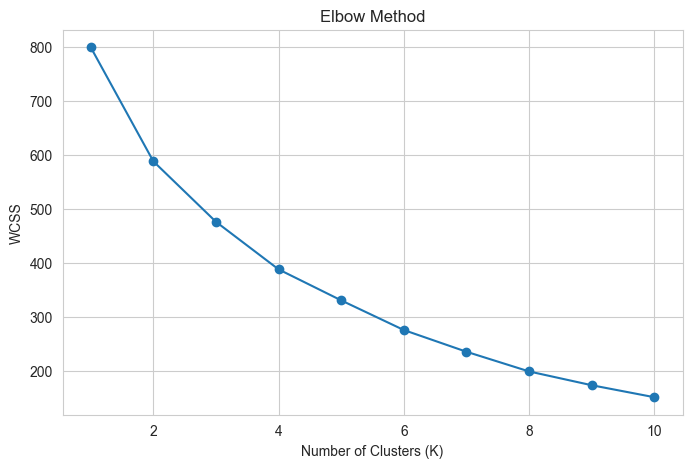

In [121]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(mall_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)
plt.show()


**Observation**

The Elbow Method indicates that the optimal number of clusters is **5**. After K = 5, the decrease in WCSS becomes more gradual, suggesting that adding more clusters provides only a small improvement.

#### Training the K-Means Model

In [122]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans_clusters = kmeans.fit_predict(mall_scaled)
mall_processed["KMeans_Cluster"] = kmeans_clusters

mall_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


#### Cluster Visualization

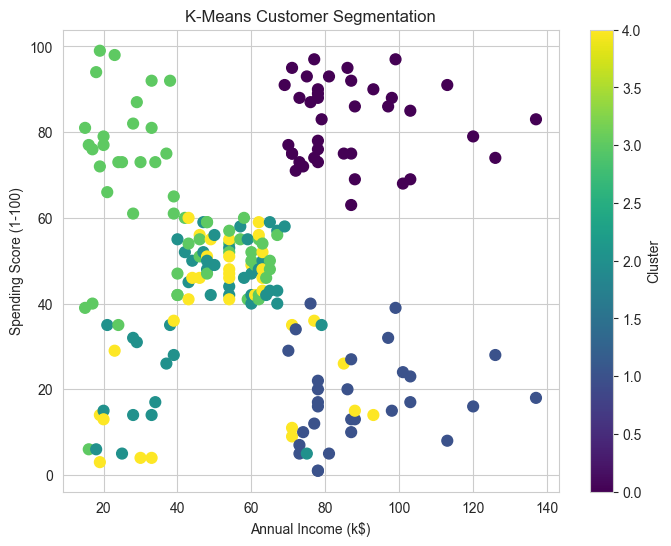

In [123]:
plt.figure(figsize=(8,6))
plt.scatter(
    mall_processed["Annual Income (k$)"],
    mall_processed["Spending Score (1-100)"],
    c=mall_processed["KMeans_Cluster"],
    cmap="viridis",
    s=60
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Customer Segmentation")
plt.colorbar(label="Cluster")
plt.show()


#### Evaluation Metrics

The performance of the K-Means clustering model is evaluated using the following metrics:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score

In [124]:
silhouette = silhouette_score(mall_scaled, kmeans_clusters)
davies = davies_bouldin_score(mall_scaled, kmeans_clusters)
calinski = calinski_harabasz_score(mall_scaled, kmeans_clusters)

print("Silhouette Score:", round(silhouette, 3))
print("Davies-Bouldin Index:", round(davies, 3))
print("Calinski-Harabasz Score:", round(calinski, 3))


Silhouette Score: 0.304
Davies-Bouldin Index: 1.167
Calinski-Harabasz Score: 68.965


**Observation**

The K-Means model achieved a **Silhouette Score of 0.304**, indicating a moderate level of cluster separation. The **Davies-Bouldin Index of 1.167** suggests that the clusters are reasonably distinct, while the **Calinski-Harabasz Score of 68.965** indicates acceptable cluster compactness and separation. Overall, K-Means produced meaningful customer segments for this dataset.

####  Hierarchical Clustering

Hierarchical Clustering is applied to the Mall Customers dataset to group customers based on similar characteristics. Ward linkage is used because it minimizes the variance within clusters.

##### Dendrogram

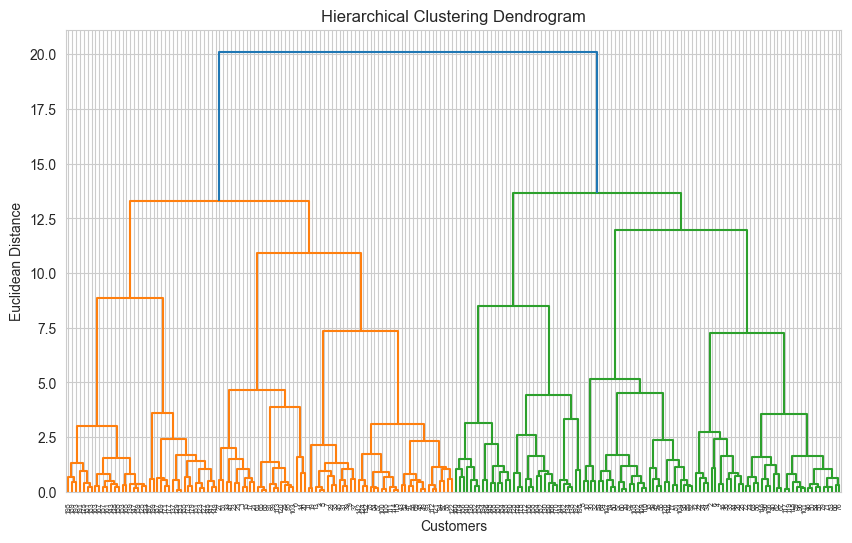

In [125]:
plt.figure(figsize=(10,6))

dendrogram(
    linkage(mall_scaled, method="ward")
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()


**Observation**

The dendrogram suggests that **5 clusters** provide a reasonable partition of the dataset. Therefore, Agglomerative Clustering is trained using **5 clusters** with Ward linkage.

####  Training the Model

In [126]:
hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)
hierarchical_clusters = hierarchical.fit_predict(mall_scaled)
mall_processed["Hierarchical_Cluster"] = hierarchical_clusters
mall_processed.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Hierarchical_Cluster
0,1,19,15,39,3,0
1,1,21,15,81,3,0
2,0,20,16,6,3,3
3,0,23,16,77,3,0
4,0,31,17,40,3,3


#### Cluster Visualization

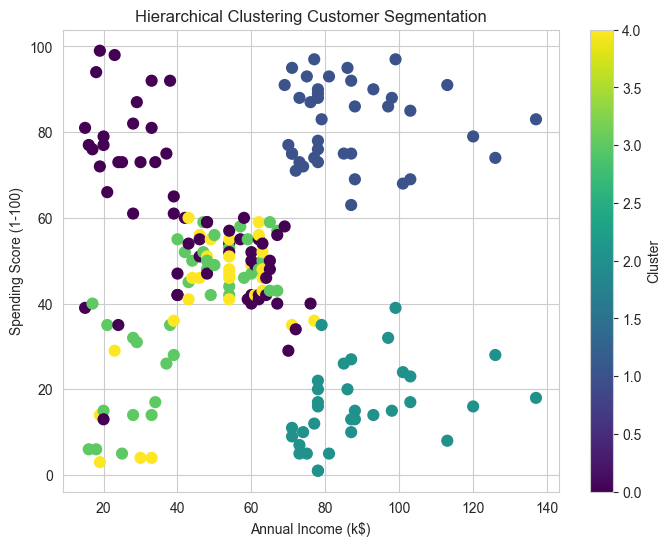

In [127]:
plt.figure(figsize=(8,6))
plt.scatter(
    mall_processed["Annual Income (k$)"],
    mall_processed["Spending Score (1-100)"],
    c=mall_processed["Hierarchical_Cluster"],
    cmap="viridis",
    s=60
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering Customer Segmentation")
plt.colorbar(label="Cluster")
plt.show()


**Observation**

Hierarchical Clustering grouped the customers into **5 clusters** based on their similarities. The visualization shows distinct customer segments according to Annual Income and Spending Score, enabling effective customer segmentation.

#### Evaluation Metrics

In [128]:
hierarchical_silhouette = silhouette_score(mall_scaled, hierarchical_clusters)
hierarchical_davies = davies_bouldin_score(mall_scaled, hierarchical_clusters)
hierarchical_calinski = calinski_harabasz_score(mall_scaled, hierarchical_clusters)

print("Silhouette Score:", round(hierarchical_silhouette, 3))
print("Davies-Bouldin Index:", round(hierarchical_davies, 3))
print("Calinski-Harabasz Score:", round(hierarchical_calinski, 3))

Silhouette Score: 0.287
Davies-Bouldin Index: 1.22
Calinski-Harabasz Score: 64.469


**Observation**

The Hierarchical Clustering model achieved a **Silhouette Score of 0.287**, a **Davies-Bouldin Index of 1.220**, and a **Calinski-Harabasz Score of 64.469**. These results indicate moderate cluster separation and compactness. Compared with K-Means, the clustering quality is slightly lower on this dataset.

#### DBSCAN

**Training the Model**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together densely packed data points while identifying points in low-density regions as noise. Unlike K-Means, it does not require specifying the number of clusters beforehand.

In [129]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(mall_scaled)

mall_processed["DBSCAN_Cluster"] = dbscan_clusters

print("Unique Cluster Labels:", np.unique(dbscan_clusters))
print("\nCluster Counts:")
print(pd.Series(dbscan_clusters).value_counts().sort_index())

Unique Cluster Labels: [-1  0  1  2  3  4]

Cluster Counts:
-1    19
 0     9
 1    94
 2    40
 3    26
 4    12
Name: count, dtype: int64


**Observation**

DBSCAN identified multiple clusters and labeled some observations as **noise (-1)**. These noise points do not belong to any dense region and are treated as outliers by the algorithm.

#### Cluster Visualization

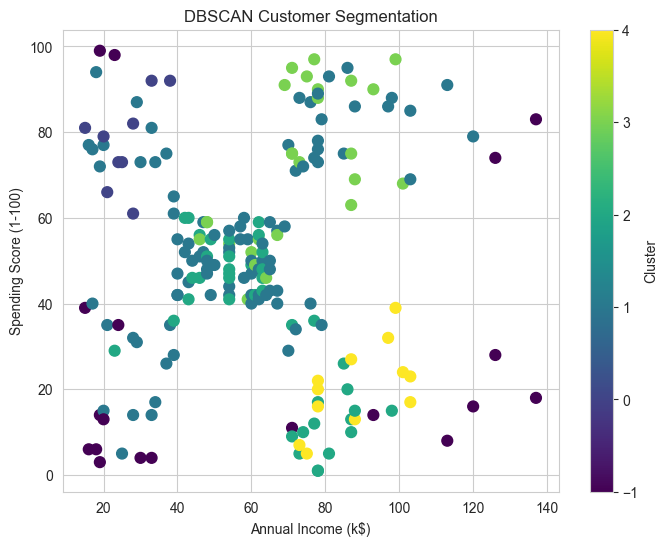

In [130]:
plt.figure(figsize=(8,6))
plt.scatter(
    mall_processed["Annual Income (k$)"],
    mall_processed["Spending Score (1-100)"],
    c=mall_processed["DBSCAN_Cluster"],
    cmap="viridis",
    s=60
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Customer Segmentation")

plt.colorbar(label="Cluster")
plt.show()


#### Evaluation Metrics

In [131]:
# Ignore noise points (-1) when evaluating DBSCAN
mask = dbscan_clusters != -1

dbscan_silhouette = silhouette_score(
    mall_scaled[mask],
    dbscan_clusters[mask]
)
dbscan_davies = davies_bouldin_score(
    mall_scaled[mask],
    dbscan_clusters[mask]
)
dbscan_calinski = calinski_harabasz_score(
    mall_scaled[mask],
    dbscan_clusters[mask]
)
print("Silhouette Score:", round(dbscan_silhouette, 3))
print("Davies-Bouldin Index:", round(dbscan_davies, 3))
print("Calinski-Harabasz Score:", round(dbscan_calinski, 3))


Silhouette Score: 0.227
Davies-Bouldin Index: 1.082
Calinski-Harabasz Score: 43.078


**Observation**

The DBSCAN model achieved a **Silhouette Score of 0.227**, a **Davies-Bouldin Index of 1.082**, and a **Calinski-Harabasz Score of 43.078**. Although DBSCAN successfully identified noise points, its overall clustering quality on this dataset is lower than K-Means and Hierarchical Clustering.

#### Cluster Comparison Table

Comparison K-Means, Hierarchical Clustering, and DBSCAN

In [132]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette Score": [
        round(silhouette, 3),
        round(hierarchical_silhouette, 3),
        round(dbscan_silhouette, 3)
    ],
    "Davies-Bouldin Index": [
        round(davies, 3),
        round(hierarchical_davies, 3),
        round(dbscan_davies, 3)
    ],
    "Calinski-Harabasz Score": [
        round(calinski, 3),
        round(hierarchical_calinski, 3),
        round(dbscan_calinski, 3)
    ]
})

comparison

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,0.304,1.167,68.965
1,Hierarchical,0.287,1.220,64.469
2,DBSCAN,0.227,1.082,43.078


**Observation**

Among the three clustering algorithms, **K-Means** achieved the highest Silhouette Score (**0.304**) and the highest Calinski-Harabasz Score (**68.965**), indicating better cluster separation and compactness. Although **DBSCAN** obtained the lowest Davies-Bouldin Index (**1.082**), its lower Silhouette and Calinski-Harabasz scores suggest that it was less effective on this dataset. Overall, **K-Means produced the best clustering performance for the Mall Customers dataset.**

#### PCA Visualization

Principal Component Analysis (PCA) is applied to reduce the four-dimensional customer data into two principal components. This makes it easier to visualize the clusters generated by the clustering algorithms.

In [133]:
mall_pca = PCA(n_components=2)
mall_pca_data = mall_pca.fit_transform(mall_scaled)
mall_pca_df = pd.DataFrame(
    mall_pca_data,
    columns=["PC1", "PC2"]
)
mall_pca_df.head()

,PC1,PC2
0,-0.406383,-0.520714
1,-1.427673,-0.367310
2,0.050761,-1.894068
3,-1.694513,-1.631908
4,-0.313108,-1.810483


##### PCA Scatter Plot

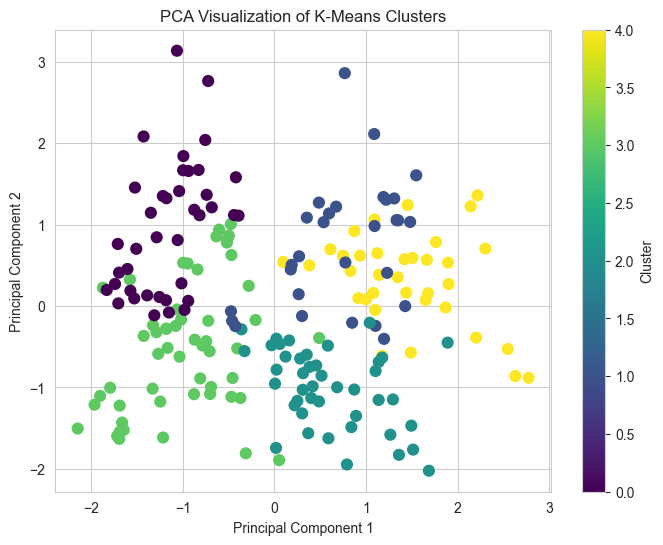

In [134]:
plt.figure(figsize=(8,6))
plt.scatter(
    mall_pca_df["PC1"],
    mall_pca_df["PC2"],
    c=kmeans_clusters,
    cmap="viridis",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of K-Means Clusters")

plt.colorbar(label="Cluster")
plt.show()

**Observation**

The PCA visualization projects the customer data onto two principal components while preserving most of the important information. The K-Means clusters appear reasonably separated, making it easier to interpret the customer segments in two-dimensional space.

## Part 6 – Feature Engineering Experiment

##### Data Loading

In [135]:
titanic_df = pd.read_csv("data/raw/titanic_dataset.csv")
print("Dataset Shape:", titanic_df.shape)
titanic_df.head()


Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [136]:
# Drop unnecessary columns
titanic_df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)

# Fill missing values
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])

# Encode categorical variables
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})
titanic_df = pd.get_dummies(
    titanic_df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)
print("Dataset Shape:", titanic_df.shape)
titanic_df.head()


Dataset Shape: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


**Preprocessing Summary**

The following preprocessing steps were performed before feature engineering:

- **Dropped Unnecessary Columns:** Removed `PassengerId`, `Name`, `Ticket`, and `Cabin` because they do not contribute significantly to prediction.
- **Handled Missing Values:** Missing values in `Age` were filled using the median, while missing values in `Embarked` were replaced with the most frequent category.
- **Encoded Categorical Variables:** `Sex` was converted into numerical values using label encoding, and `Embarked` was transformed using one-hot encoding.

#### Baseline Model (Without Feature Engineering)

A Logistic Regression model is trained on the preprocessed Titanic dataset before applying any feature engineering techniques. The resulting accuracy serves as the baseline for comparing the performance after creating new features.

In [143]:
X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline Accuracy:", round(baseline_accuracy, 4))


Baseline Accuracy: 0.8101


**Observation**

The baseline Logistic Regression model achieved an accuracy of **0.8101** before applying feature engineering. This result will be used as the reference for evaluating the effect of newly engineered features.

#### Polynomial Features

Polynomial features are created from the numerical variables to capture more complex relationships between them. These additional features may help the model learn patterns that are not represented by the original variables alone.

In [145]:
# Select numerical features
numerical_features = ["Age", "Fare", "SibSp", "Parch"]

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)
poly_features = poly.fit_transform(
    titanic_df[numerical_features]
)
poly_feature_names = poly.get_feature_names_out(numerical_features)

poly_df = pd.DataFrame(
    poly_features,
    columns=poly_feature_names,
    index=titanic_df.index
)
print("Original Numerical Features:", len(numerical_features))
print("Polynomial Features Created:", poly_df.shape[1])
poly_df.head()


Original Numerical Features: 4
Polynomial Features Created: 14


,Age,Fare,SibSp,Parch,Age^2,Age Fare,Age SibSp,Age Parch,Fare^2,Fare SibSp,Fare Parch,SibSp^2,SibSp Parch,Parch^2
0,22.0,7.2500,1.0,0.0,484.0,159.5000,22.0,0.0,52.562500,7.2500,0.0,1.0,0.0,0.0
1,38.0,71.2833,1.0,0.0,1444.0,2708.7654,38.0,0.0,5081.308859,71.2833,0.0,1.0,0.0,0.0
2,26.0,7.9250,0.0,0.0,676.0,206.0500,0.0,0.0,62.805625,0.0000,0.0,0.0,0.0,0.0
3,35.0,53.1000,1.0,0.0,1225.0,1858.5000,35.0,0.0,2819.610000,53.1000,0.0,1.0,0.0,0.0
4,35.0,8.0500,0.0,0.0,1225.0,281.7500,0.0,0.0,64.802500,0.0000,0.0,0.0,0.0,0.0


**Observation**

The number of numerical features increased from **4** to **14** after applying Polynomial Features. In addition to the original features, the transformation generated squared terms (such as `Age²` and `Fare²`) and interaction terms (such as `Age × Fare` and `Fare × SibSp`), providing more information for the model to learn from.

#### Interaction Features

Interaction features are created by multiplying pairs of numerical variables. Unlike polynomial features, interaction features do not include squared terms and focus only on the combined effect of two different variables.

In [146]:
interaction = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)
interaction_features = interaction.fit_transform(
    titanic_df[numerical_features]
)
interaction_feature_names = interaction.get_feature_names_out(
    numerical_features
)
interaction_df = pd.DataFrame(
    interaction_features,
    columns=interaction_feature_names,
    index=titanic_df.index
)
print("Original Numerical Features:", len(numerical_features))
print("Interaction Features Created:", interaction_df.shape[1])

interaction_df.head()


Original Numerical Features: 4
Interaction Features Created: 10


,Age,Fare,SibSp,Parch,Age Fare,Age SibSp,Age Parch,Fare SibSp,Fare Parch,SibSp Parch
0,22.0,7.2500,1.0,0.0,159.5000,22.0,0.0,7.2500,0.0,0.0
1,38.0,71.2833,1.0,0.0,2708.7654,38.0,0.0,71.2833,0.0,0.0
2,26.0,7.9250,0.0,0.0,206.0500,0.0,0.0,0.0000,0.0,0.0
3,35.0,53.1000,1.0,0.0,1858.5000,35.0,0.0,53.1000,0.0,0.0
4,35.0,8.0500,0.0,0.0,281.7500,0.0,0.0,0.0000,0.0,0.0


**Observation**

The number of numerical features increased from **4** to **10** after creating Interaction Features. The transformation generated only interaction terms between different variables, such as `Age × Fare` and `Fare × SibSp`, without creating squared features.

#### Binning

Binning groups continuous numerical values into a small number of categories. This can help the model identify broader patterns by reducing the effect of small variations in the data.

In [147]:
titanic_fe = titanic_df.copy()

titanic_fe["Age_Group"] = pd.cut(
    titanic_fe["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)
titanic_fe["Age_Group"] = titanic_fe["Age_Group"].cat.codes
print("Age Group Distribution:")
print(titanic_fe["Age_Group"].value_counts().sort_index())

titanic_fe[["Age", "Age_Group"]].head()

Age Group Distribution:
Age_Group
0     69
1     70
2    535
3    195
4     22
Name: count, dtype: int64


,Age,Age_Group
0,22.0,2
1,38.0,3
2,26.0,2
3,35.0,2
4,35.0,2


**Observation**

The continuous **Age** feature was grouped into **five categories**: Child, Teen, Young Adult, Adult, and Senior. Most passengers belong to the **Young Adult** group (535), followed by the **Adult** group (195). This transformation simplifies the age information and may help the model identify patterns based on age groups rather than exact ages.

#### Date Features

The Titanic dataset does not contain any date or time-related attributes. Therefore, no date-based features were created for this experiment.

### Model Training with Feature Engineering

The engineered features were combined with the original dataset, and the Logistic Regression model was trained again. The model's performance was then compared with the baseline model to evaluate the impact of feature engineering.

In [148]:
# Keep only the newly generated polynomial features
poly_new = poly_df.drop(columns=numerical_features)
# Combine original dataset with engineered features
titanic_engineered = pd.concat(
    [
        titanic_df,
        poly_new,
        titanic_fe[["Age_Group"]]
    ],
    axis=1
)
print("Original Dataset Shape:", titanic_df.shape)
print("Feature Engineered Dataset Shape:", titanic_engineered.shape)


Original Dataset Shape: (891, 9)
Feature Engineered Dataset Shape: (891, 20)


#### Training the Model

In [149]:
X_fe = titanic_engineered.drop("Survived", axis=1)
y_fe = titanic_engineered["Survived"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42
)
fe_model = LogisticRegression(max_iter=5000)

fe_model.fit(X_train_fe, y_train_fe)

fe_predictions = fe_model.predict(X_test_fe)

fe_accuracy = accuracy_score(y_test_fe, fe_predictions)

print("Accuracy After Feature Engineering:", round(fe_accuracy, 4))


Accuracy After Feature Engineering: 0.8156


#### Performance Comparison

In [150]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Without Feature Engineering)",
              "Logistic Regression (With Feature Engineering)"],
    "Accuracy": [
        round(baseline_accuracy, 4),
        round(fe_accuracy, 4)
    ]
})

comparison


,Model,Accuracy
0,Logistic Regression (Without Feature Engineering),0.8101
1,Logistic Regression (With Feature Engineering),0.8156


After training the Logistic Regression model on the engineered dataset, the model's accuracy improved from **0.8101** to **0.8156**. This demonstrates that carefully engineered features can provide additional information to the model and contribute to improved prediction performance.

### Conclusion

This notebook demonstrated the complete workflow of unsupervised learning and feature engineering. Different preprocessing techniques, clustering algorithms, PCA, and anomaly detection methods were implemented and evaluated on real-world datasets. The clustering results showed that K-Means performed best for the selected dataset, while feature engineering slightly improved the accuracy of the Logistic Regression model on the Titanic dataset. Overall, the assignment highlighted the importance of data preparation, feature engineering, and appropriate algorithm selection in improving machine learning performance.